#Projeto da Disciplina Aplicação de Inteligência Artificial em Problema Real 🤖
------------------------------------------------------------------------------
## Desenvolvimento e Avaliação de Modelos de Machine Learning para Detecção de Doença Arterial Coronariana: Explicabilidade e Análise de Erros de Classificação 💔
------------------------------------------------------------------------------
### Projeto desenvolvido por:
####Ana Clara Gierse Raymundo: 10428453 👩
####Erica Gonçalves de Oliveira: 10428547 👩
####Luana Domingos Branco: 10428459 👩
####Victor Luiz de Sá Alves: 10426310 👨
------------------------------------------------------------------------------
### Síntese do conteúdo
#### Este arquivo fonte contém o código Python para execução da Análise exploratória de Dados (EDA) do dataset Z-Alizadeh Sani, incluindo verificação de integridade, estatísticas descritivas e visualização gráfica.

------------------------------------------------------------------------------
#### 10/09/2026 | Victor Alves      | Criação do script inicial e ajuste da leitura em .xlsx.
#### 10/09/2026 | Ana Clara         | Implementação das estatísticas descritivas e gráficos da variável Cath.
#### 11/09/2026 | Erica Oliveira    | Adicionada a matriz de correlação das variáveis numéricas.
#### 12/09/2026 | Luana Branco      | Inclusão dos gráficos de contagem dos fatores de risco.


###Importação e configurações iniciais
#### Análise exploratória

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

caminho_arquivo = '/content/sample_data/Z-Alizadeh sani dataset.xlsx'

try:
    df = pd.read_excel(caminho_arquivo)
    print("✅ Arquivo .xlsx carregado com sucesso!")
except FileNotFoundError:
    print(f"❌ Arquivo não encontrado em '{caminho_arquivo}'. Verifique se fez o upload no painel lateral do Colab.")

✅ Arquivo .xlsx carregado com sucesso!


### Inspeção Geral e Qualidade dos Dados

In [2]:
print("\n=== Dimensões do Dataset ===")
print(f"Linhas (Pacientes): {df.shape[0]} | Colunas (Características): {df.shape[1]}")

print("\n=== Verificação de Dados Ausentes e Duplicados ===")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")  # Confirma ausência de nulos conforme UCI
print(f"Linhas duplicadas: {df.duplicated().sum()}")


=== Dimensões do Dataset ===
Linhas (Pacientes): 303 | Colunas (Características): 56

=== Verificação de Dados Ausentes e Duplicados ===
Total de valores nulos: 0
Linhas duplicadas: 0


### Análise da Variável Alvo


=== Distribuição da Variável Alvo ('Cath') ===


,Frequência,Percentual (%)
Cath,,
Cad,216,71.29
Normal,87,28.71


/tmp/ipykernel_5801/3431995465.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(data=df, x='Cath', palette='viridis')


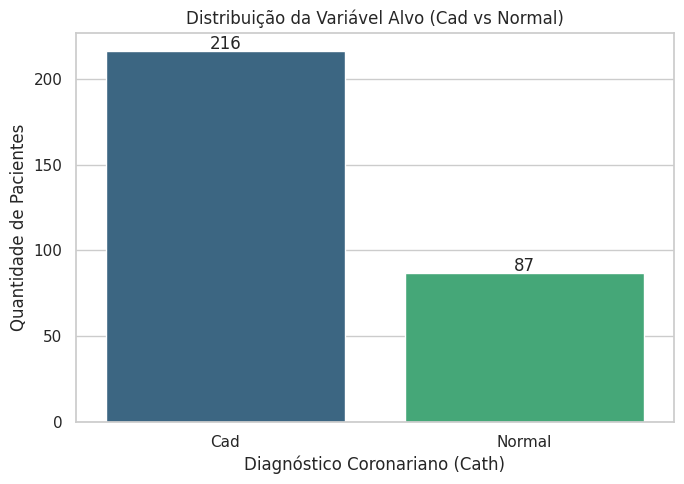

In [3]:
print("\n=== Distribuição da Variável Alvo ('Cath') ===")
contagem_alvo = df['Cath'].value_counts()
percentual_alvo = df['Cath'].value_counts(normalize=True) * 100

df_alvo = pd.DataFrame({'Frequência': contagem_alvo, 'Percentual (%)': percentual_alvo.round(2)})
display(df_alvo)

plt.figure(figsize=(7, 5))
ax = sb.countplot(data=df, x='Cath', palette='viridis')
plt.title('Distribuição da Variável Alvo (Cad vs Normal)')
plt.xlabel('Diagnóstico Coronariano (Cath)')
plt.ylabel('Quantidade de Pacientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Relação entre Fatores de Risco Categóricos e Diagnóstico

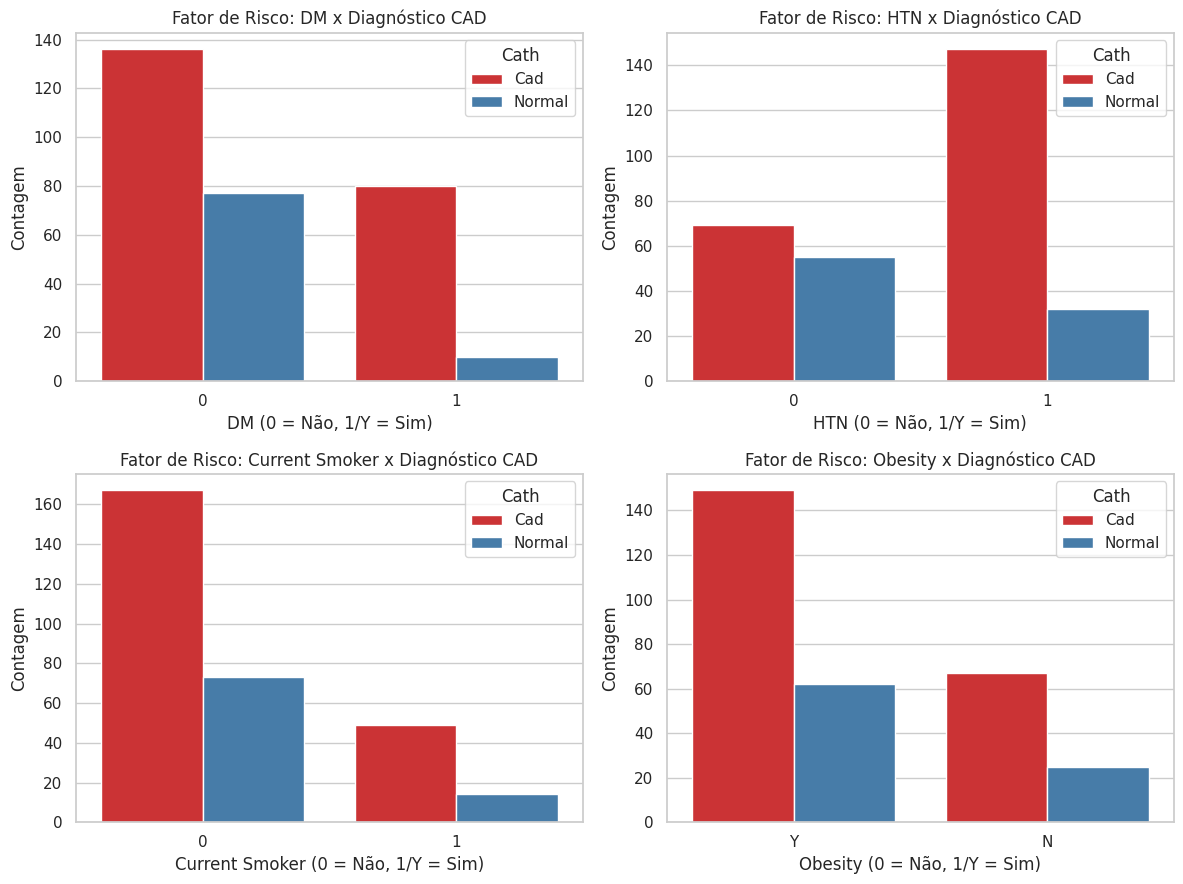

In [4]:
fatores_risco = ['DM', 'HTN', 'Current Smoker', 'Obesity']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(fatores_risco):
    sb.countplot(data=df, x=col, hue='Cath', palette='Set1', ax=axes[i])
    axes[i].set_title(f'Fator de Risco: {col} x Diagnóstico CAD')
    axes[i].set_xlabel(f'{col} (0 = Não, 1/Y = Sim)')
    axes[i].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### Matriz de Correlação das Variáveis Numéricas Chave

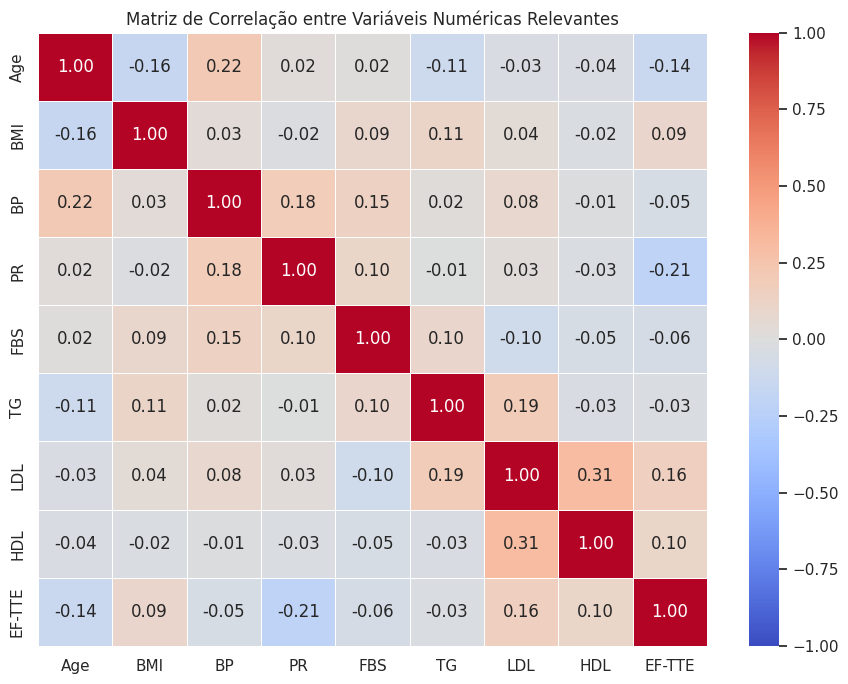

In [5]:
cols_numericas = ['Age', 'BMI', 'BP', 'PR', 'FBS', 'TG', 'LDL', 'HDL', 'EF-TTE']

plt.figure(figsize=(9, 7))
matriz_corr = df[cols_numericas].corr()
sb.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas Relevantes')
plt.tight_layout()
plt.show()